# Математическая статистика для анализа больших данных.
## Семинар 2
### Метод бутстрепа

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

### Бутстреп

In [4]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from skimage.transform import resize
import scipy.stats as sps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Имеются картинки пяти зверей, это наша выборка. Нужно оценить дисперсию среднего значения зверей. Для каждого пикселя картинки и для каждого цветового канала все операции проводим отдельно.

Загружаем картинки зверюшек и приводим их к размеру 500 на 500. Каждая картинка представляется в виде трехмерной матрицы размера (500, 500, 3) чисел от 0 до 1. Первые две размерности отвечают за высоту и ширину картинки, третья за цветовые каналы --- красный, зеленый, синий.

По сути у нас есть выборка размера 5 из $(500 \cdot 500 \cdot 3)$-мерного пространства.

In [ ]:
n = 5
images = [plt.imread('./animal_{}.jpg'.format(i+1)) for i in range (n)]
images = [resize(images[i], (500, 500, 3)) for i in range (n)]

Визуализируем все изображения при помощи функции `plt.imshow`. Вызов функций `plt.xticks([]), plt.yticks([])` убирает подписи к координатным осям, `plt.tight_layout`  обрезает пустые поля графиков, а `facecolor=(0,0,0,0)` делает фон графика прозрачным при сохранении (четыре числа -- красный, зеленый, синий, прозрачность).

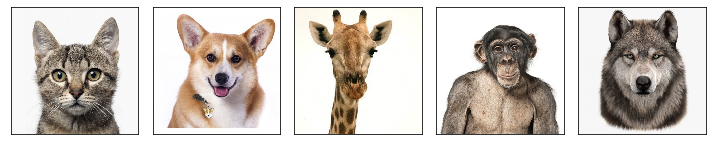

In [ ]:
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.savefig('zoo.png', facecolor=(0,0,0,0))
plt.show()

Для визуализации загрузим изображение стрелки

In [ ]:
arrow = plt.imread('./arrow.png')

Функция, реализующая бутстреп

In [ ]:
def zoo_bootstrap(images, B=6, draw=False):
    '''
    Генерирует B бутстрепных выборок изображений
    и возвращает среднее по каждой из них.
    Если указан параметр draw, то рисует процесс на графике.
    '''

    n = len(images)
    bootstrap_means = []  # средние по бутстрепным выборкам

    if draw:
        plt.figure(figsize=(11.5, 9.5))

    for b in range(B):
        # сумма элементов в бутстрепной выборке
        sum_bsample = 0

        for i in range(n):
            # генерируем элемент бутстрепной выборки
            ind = sps.randint(low=0, high=n).rvs()
            # добавляем его к сумме по этой выборке
            sum_bsample += images[ind]

            # визуализация элемента бутстрепной выборки
            if draw:
                plt.subplot(B, n+2, b*(n+2)+i+1)
                plt.imshow(images[ind])
                plt.xticks([]), plt.yticks([])
                if i == 0:
                    plt.ylabel('$X^*_{}$:       '.format(b+1),
                               rotation=0, fontsize=26)

        # добавляем среднее по бутстрепной выборке
        bootstrap_means.append(sum_bsample/n)

        if draw:
            # стрелка
            plt.subplot(B, n+2, b*(n+2)+i+2)
            plt.imshow(arrow)
            plt.axis('off'), plt.xticks([]), plt.yticks([])
            # среднее по бутстрепной выборке
            plt.subplot(B, n+2, b*(n+2)+i+3)
            plt.imshow(bootstrap_means[-1])
            plt.xticks([]), plt.yticks([])

    if draw:
        plt.tight_layout()
        plt.savefig('zoo_bootstrap.png', facecolor=(0,0,0,0))
        plt.show()

    return bootstrap_means

Посмотрим, что получается на выборках размера 6. Ниже изображена схема бутстрепа. По строкам изображены бутстрепные выборки (разумеется, размера 5). В последнем столбце по каждой бутстрепной выборке посчитано среднее всех пикселей.

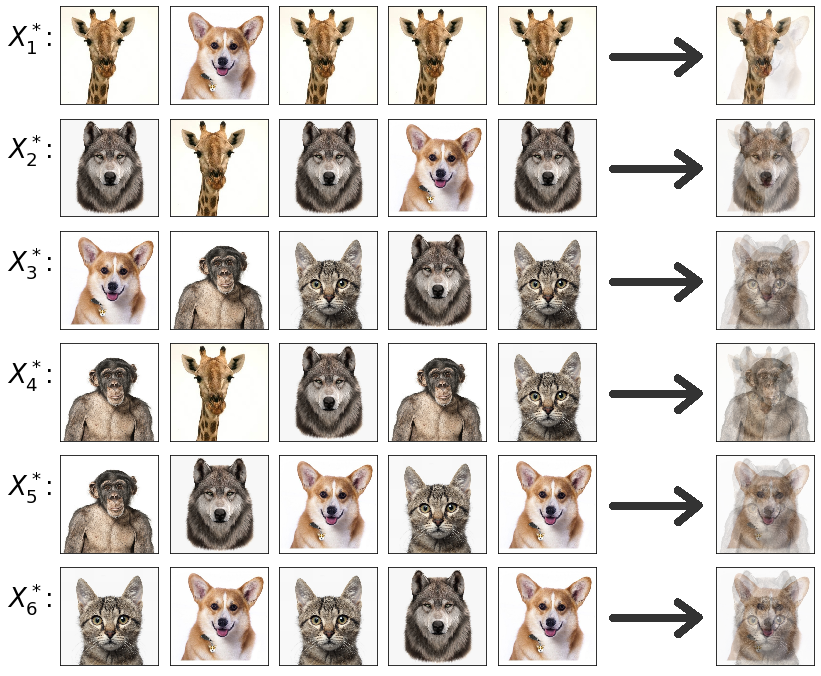

In [ ]:
bootstrap_means = zoo_bootstrap(images, draw=True)

По бутстрепной выборке средних (правый столбец выше) можем посчитать выборочную дисперсию для каждого пикселя. Поскольку цвета изображения должны быть от 0 до 1, для визуализации нормируем все дисперсии на максимальное значение по всем пикселям и цветовым каналам. Очевидно, что минимальное значение дисперсий равно нулю --- в крайних пикселях всегда белый фон.

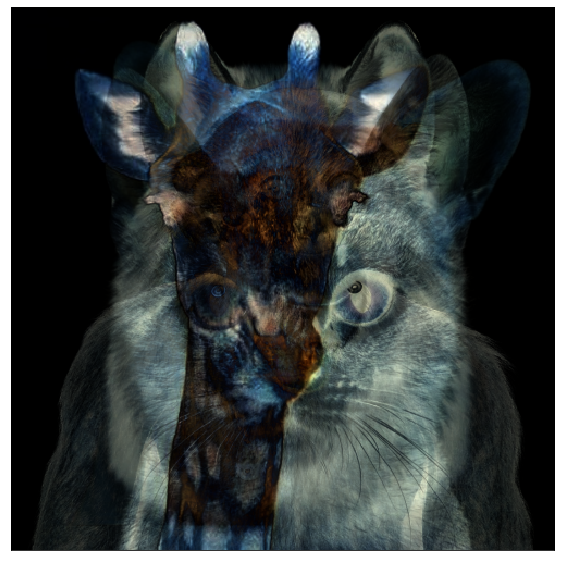

In [ ]:
bootstrap_var = np.var(bootstrap_means, axis=0)
bvar_normed = bootstrap_var / bootstrap_var.max(axis=(0, 1)).reshape((1, 1, 3))

plt.figure(figsize=(10, 10))
plt.imshow(bvar_normed)
plt.xticks([]), plt.yticks([]);
plt.savefig('zoo_bootstrap_var.png', facecolor=(0,0,0,0))
plt.show()

Посмотрим на результат при большем количестве бутстрепных выборок

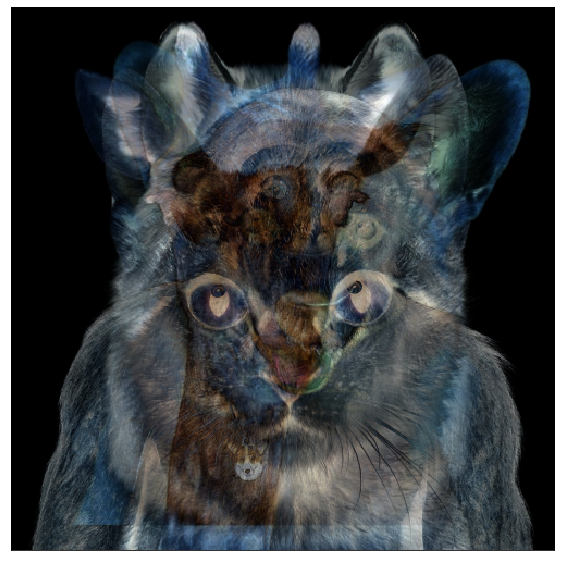

In [ ]:
bootstrap_means = zoo_bootstrap(images, B=300)
bootstrap_var = np.var(bootstrap_means, axis=0)
bvar_normed = bootstrap_var / bootstrap_var.max(axis=(0, 1)).reshape((1, 1, 3))

plt.figure(figsize=(10, 10))
plt.imshow(bvar_normed)
plt.xticks([]), plt.yticks([]);
plt.savefig('zoo_bootstrap_var.png', facecolor=(0,0,0,0))
plt.show()

##  Задача 1 (самостоятельное решение)

Вам предложены два файла. Один содержит предсказанные данные о спросе велосипедов в прокате, а другой - реальные за этот же период.

Для метрик MSE, MAE, MAPE постройте бутстрепные доверительные интервалы трех типов: нормальный, квантильный и центральный.

In [5]:
# Загрузим данные
real_data = np.array(pd.read_csv("real_data.txt", sep=" ")).flatten()
pred_data = np.array(pd.read_csv("predictions.txt", sep=" ")).flatten()

Посчитайте MSE, MAE, MAPE для этих данных:

In [6]:
mse = np.mean((real_data - pred_data)**2)
print(mse)

mae = np.mean(np.abs(real_data - pred_data))
print(mae)

mape = np.mean(np.abs((real_data - pred_data)/real_data))
print(mape)

1806039.803088549
1164.821858511042
0.3258853030473872


#### Нормальный интервал

У нас есть оценка на все три метрики. Оценим дисперсию, как:
$$
\sigma^2 = S^2,
$$

т.к. мы знаем, что это состоятельная оценка. $S^2$ посчитаем через бутстрепную выборку.

Для MSE наша оценка:
$$
\widehat{\theta} = \sum\limits_{i=1}^n\frac{(y_i - y_{i,true})^2}{n} = \overline{(y - y_{true})^2}
$$
По ЦПТ эта оценка является а.н.о. для $MSE = E_{\theta}(y_1 - y_{1, true})^2$, а асимптотическую дисперсию оценим как $S^2$, так как она состоятельная.

То есть нам необходимо сгенерировать $B$ бутстрепных выборок, по ним посчитать MSE и по ним дисперсию.

In [38]:
#Выберите В. Сгенерируйте B бутстрепных выборок.

B = 1000
bootstrap_mse = []

def gen_bootstrap_samples(sample, B):
  bootstrap_samples = []
  for i in range(B):
    bootstrap_samples.append(
        sample[np.random.randint(0, len(sample), len(sample))])
  return bootstrap_samples

bootstrap_samples = gen_bootstrap_samples(pred_data, B)

In [39]:
def calc_norm_conf_interval(est_theta, sample_stat, n, alpha = 0.95):
    lower_bound = est_theta - (1 - alpha) * np.std(sample_stat) / np.sqrt(n)
    upper_bound = est_theta + (1 - alpha) * np.std(sample_stat) / np.sqrt(n)
    return lower_bound, upper_bound

def calc_quantile_conf_interval(est_theta, sample_stat, n, alpha = 0.95):
    lower_bound = np.quantile(sample_stat, alpha / 2)
    upper_bound = np.quantile(sample_stat, 1 - alpha / 2)
    return lower_bound, upper_bound

def calc_center_conf_interval(est_theta, sample_stat, n, alpha = 0.95):
    lower_bound = np.mean(sample_stat) - (1 - alpha) * np.std(sample_stat) / np.sqrt(n)
    upper_bound = np.mean(sample_stat) + (1 - alpha) * np.std(sample_stat) / np.sqrt(n)
    return lower_bound, upper_bound

Посчитайте MSE по сгенерированным выборкам и передайте их в реализованную функцию.

Интервал для какой метрики получился наиболее точным?

In [44]:
def calc_mse(sample):
  return np.mean((sample - real_data)**2)

bootstrap_mse = [calc_mse(sample) for sample in bootstrap_samples]
bootstrap_mae = [np.mean(np.abs(sample - real_data)) for sample in bootstrap_samples]
bootstrap_mape = [np.mean(np.abs((sample - real_data)/real_data)) for sample in bootstrap_samples]

print("MSE:")
print(calc_norm_conf_interval(mse, bootstrap_mse, B))
print("MAE:")
print(calc_norm_conf_interval(mae, bootstrap_mae, B))
print("MAPE:")
print(calc_norm_conf_interval(mape, bootstrap_mape, B))

MSE:
(1805190.309055693, 1806889.2971214051)
MAE:
(1164.663405022247, 1164.9803119998369)
MAPE:
(0.32581577999684685, 0.3259548260979276)


Интервал получился более точным для метрики MAPE

Сделайте то же самое для квантильного и центрального интервалов.

В каких случаях вам может пригодиться такой метод построения интервалов?

In [47]:
import pandas as pd

mse_norm_left, mse_norm_right = calc_norm_conf_interval(mse, bootstrap_mse, B)
mse_quant_left, mse_quant_right = calc_quantile_conf_interval(mse, bootstrap_mse, B)
mse_center_left, mse_center_right = calc_center_conf_interval(mse, bootstrap_mse, B)

mae_norm_left, mae_norm_right = calc_norm_conf_interval(mae, bootstrap_mae, B)
mae_quant_left, mae_quant_right = calc_quantile_conf_interval(mae, bootstrap_mae, B)
mae_center_left, mae_center_right = calc_center_conf_interval(mae, bootstrap_mae, B)

mape_norm_left, mape_norm_right = calc_norm_conf_interval(mape, bootstrap_mape, B)
mape_quant_left, mape_quant_right = calc_quantile_conf_interval(mape, bootstrap_mape, B)
mape_center_left, mape_center_right = calc_center_conf_interval(mape, bootstrap_mape, B)

data = {
    ' ': ['MSE', 'MAE', 'MAPE'],
    'Left Normal': [mse_norm_left, mae_norm_left, mape_norm_left],
    'Left Quantile': [mse_quant_left, mae_quant_left, mape_quant_left],
    'Left Center': [mse_center_left, mae_center_left, mape_center_left],
    'Value': [mse, mae, mape],
    'Right Normal': [mse_norm_right, mae_norm_right, mape_norm_right],
    'Right Quantile': [mse_quant_right, mae_quant_right, mape_quant_right],
    'Right Center': [mse_center_right, mae_center_right, mape_center_right],
}

df = pd.DataFrame(data)
print(df)


          Left Normal  Left Quantile   Left Center         Value  \
0   MSE  1.805190e+06   6.195481e+06  6.235319e+06  1.806040e+06   
1   MAE  1.164663e+03   2.036283e+03  2.039082e+03  1.164822e+03   
2  MAPE  3.258158e-01   7.085757e-01  7.102435e-01  3.258853e-01   

   Right Normal  Right Quantile  Right Center  
0  1.806889e+06    6.256596e+06  6.237018e+06  
1  1.164980e+03    2.047581e+03  2.039399e+03  
2  3.259548e-01    7.138503e-01  7.103826e-01  



В ходе выполнения задания были построены доверительные интервалы трех типов (нормальный, квантильный и центральный) для метрик MSE, MAE и MAPE, характеризующих качество предсказания спроса на велосипеды.

**Результаты:**

* **Нормальный интервал:** основан на предположении о нормальности распределения оценки.
* **Квантильный интервал:** не требует предположения о нормальности, но может быть менее точным при малом объеме данных.
* **Центральный интервал:**  также не требует предположения о нормальности, основан на среднем и стандартном отклонении бутстрепных выборок.

**Наиболее точный интервал:**  Для метрики MAPE нормальный интервал показал наибольшую точность, то есть значение метрики находится в пределах интервала.

**Применение:**

Метод бутстрепа для построения доверительных интервалов полезен в случаях, когда:
* Точное распределение оценки неизвестно или сложно рассчитать.
* Необходимо оценить неопределенность оценки, связанную с конечным размером выборки.
* Необходимо учесть возможную неоднородность выборки.


**Общий вывод:**

Полученные результаты показывают, что бутстреп является эффективным методом для построения доверительных интервалов для различных метрик качества.Выбор типа интервала зависит от конкретной задачи и имеющихся данных.
